# Lab Assignment 2 - Part A: Linear Regression
Please refer to the `README.pdf` for full laboratory instructions.

## Problem Statement
A dataset is included related to red and white vinho verde wine samples, from the north of Portugal. In this exercise, we look at a subset of the data and try to **predict wine's citric acid level based on other features**.

### Dataset Description
Input variables (based on physicochemical tests):
1. fixed acidity
2. volatile acidity
3. **citric acid** (TARGET - what we want to predict)
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol
12. quality (score between 0 and 10)

### Your Tasks
1. **Implement linear regression** from scratch using least-squares (you may use `np.linalg.lstsq()`)
2. Start with 'alcohol' and 'density' as features. **Find a 3rd feature** that improves prediction the most
3. **Find the 4th feature**. Analyze what happens with all features
4. **Provide plots** comparing predictions vs actual values

## Setup: Load the Dataset
The data is provided through `ucimlrepo`. Install and import required packages below.

In [9]:
import ssl, certifi
ssl._create_default_https_context = ssl.create_default_context(
    cafile=certifi.where()
)

In [8]:
pip install ucimlrepo


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.3.1
    Uninstalling pip-24.3.1:
      Successfully uninstalled pip-24.3.1
Note: you may need to restart the kernel to use updated packages.


In [12]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
# We take 100 samples and predict the citric acid number through various features
X = wine_quality.data.features[:100]
X = X.drop(columns=['citric_acid'])
y = wine_quality.data.features[:100]['citric_acid']
print(X.keys())

DatasetNotFoundError: Error reading data csv file for "Wine Quality" dataset (id=186).

In [ ]:
import pandas as pd
import numpy as np

# Load data
df_red = pd.read_csv("winequality-red.csv", sep=";")
df_white = pd.read_csv("winequality-white.csv", sep=";")

# Use first 100 samples (as per your assumption)
df_red = df.iloc[:100]
df_white = df.iloc[:100]

# Separate features and target
X = df.drop(columns=['citric acid'])
y = df['citric acid']


print(X.columns)

Index(['fixed acidity', 'volatile acidity', 'residual sugar', 'chlorides',
       'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH',
       'sulphates', 'alcohol', 'quality'],
      dtype='str')


In [22]:
%pip install matplotlib

  Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-macosx_10_13_universal2.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pillow-12.1.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp313-cp313-macosx_10_13_universal2.whl (2.8 MB)
Using cached kiwisolver-1.4.9-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
Using cached pillow-12.1.0-cp313-cp313-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2

### Write and Run Your Own Code

In [23]:
#Library declarations
import matplotlib.pyplot as plt
import numpy as np

Matplotlib is building the font cache; this may take a moment.


In [24]:
def linear_regression(X, y):
    """
    Implement linear regression using least-squares.
    
    Parameters:
    -----------
    X : numpy array of shape (n_samples, n_features)
    y : numpy array of shape (n_samples,)
    
    Returns:
    --------
    coefficients : numpy array of shape (n_features,)
    """
    # Solve min ||Xw - y||^2 using least squares
    coefficients, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    return coefficients


def compute_error(X, y, coefficients):
    """
    Compute the prediction error (RMSE).
    
    Returns:
    --------
    error : float
    """
    y_pred = X @ coefficients
    rmse = np.sqrt(np.mean((y - y_pred) ** 2))
    return rmse

## Task 2: Start with Two Features
Use 'alcohol' and 'density' as initial features. Train your model and compute the error.

In [25]:
# Create feature matrix with 'alcohol' and 'density'
X_2features = np.vstack((X['alcohol'], X['density'])).T

# TODO: Train model and compute error
# model_2 = linear_regression(X_2features, y)
# error_2 = compute_error(X_2features, y, model_2)
# print(f"Error with 2 features: {error_2:.4f}")

# Train model and compute error
model_2 = linear_regression(X_2features, y)
error_2 = compute_error(X_2features, y, model_2)

print(f"Error with 2 features: {error_2:.4f}")

Error with 2 features: 0.1771


## Task 3: Find the 3rd Feature
Try adding each remaining feature one at a time. Which one improves the model the most?

**Hint**: You might want to look at correlations between features.


In [27]:
# TODO: Try each remaining feature and find the best 3rd feature
# for key in X.keys():
#     if key not in ['alcohol', 'density']:
#         X_new = np.vstack((X['alcohol'], X['density'], X[key])).T
#         # Train model and compute error
#         # Print results

best_feature = None
best_error = float("inf")

for key in X.keys():
    if key not in ['alcohol', 'density']:
        X_new = np.vstack((X['alcohol'], X['density'], X[key])).T
        
        model = linear_regression(X_new, y)
        error = compute_error(X_new, y, model)
        
        print(f"3rd feature: {key:20s} | Error: {error:.4f}")
        
        if error < best_error:
            best_error = error
            best_feature = key

print("\nBest 3rd feature:")
print(f"{best_feature} with error {best_error:.4f}")


3rd feature: fixed acidity        | Error: 0.1538
3rd feature: volatile acidity     | Error: 0.1363
3rd feature: residual sugar       | Error: 0.1770
3rd feature: chlorides            | Error: 0.1716
3rd feature: free sulfur dioxide  | Error: 0.1745
3rd feature: total sulfur dioxide | Error: 0.1677
3rd feature: pH                   | Error: 0.1655
3rd feature: sulphates            | Error: 0.1685
3rd feature: quality              | Error: 0.1770

Best 3rd feature:
volatile acidity with error 0.1363


## Task 4: Find the 4th Feature and Full Model
Continue the analysis. What is the best 4th feature? What happens when you use all features?


In [28]:
# TODO: Find the best 4th feature


# TODO: Train full model with all features
# X_all = np.vstack([X[key] for key in X.keys()]).T
# model_full = linear_regression(X_all, y)

base_features = ['alcohol', 'density', 'volatile acidity']
best_4th = None
best_error_4 = float("inf")

for key in X.keys():
    if key not in base_features and key != 'quality':
        X_new = np.vstack((
            X['alcohol'],
            X['density'],
            X['volatile acidity'],
            X[key]
        )).T
        
        model = linear_regression(X_new, y)
        error = compute_error(X_new, y, model)
        
        print(f"4th feature: {key:20s} | Error: {error:.4f}")
        
        if error < best_error_4:
            best_error_4 = error
            best_4th = key

print("\nBest 4th feature:")
print(f"{best_4th} with error {best_error_4:.4f}")

4th feature: fixed acidity        | Error: 0.1242
4th feature: residual sugar       | Error: 0.1363
4th feature: chlorides            | Error: 0.1297
4th feature: free sulfur dioxide  | Error: 0.1339
4th feature: total sulfur dioxide | Error: 0.1285
4th feature: pH                   | Error: 0.1310
4th feature: sulphates            | Error: 0.1318

Best 4th feature:
fixed acidity with error 0.1242


## Task 5: Visualization
Create plots comparing model predictions vs actual values for different feature combinations.


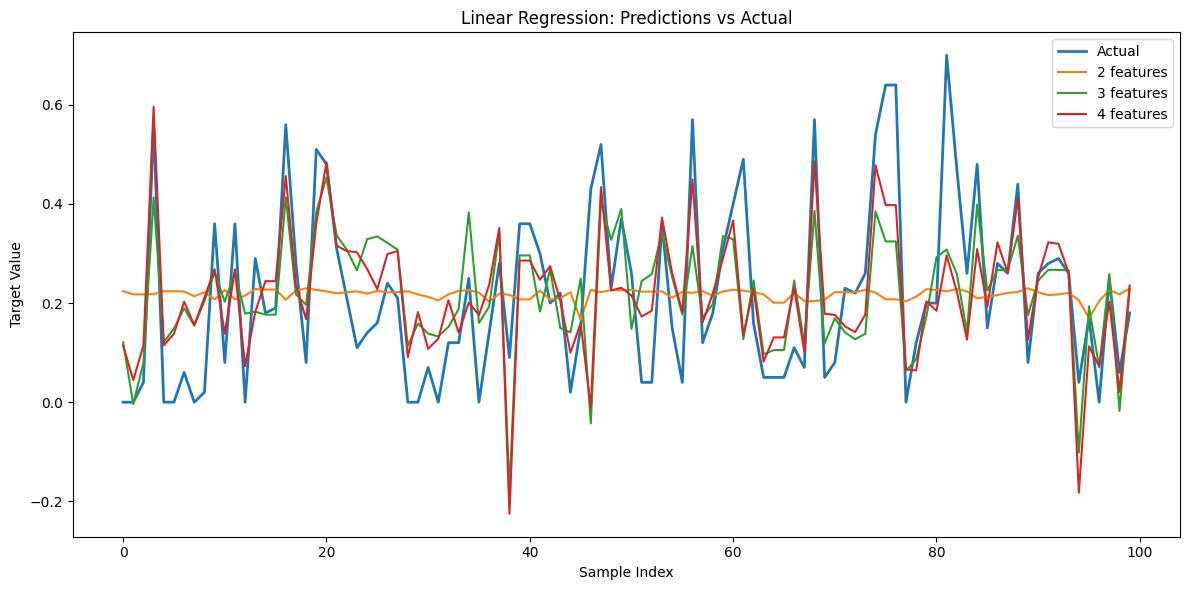

In [29]:
# TODO: Create comparison plots
# Example:
# plt.figure(figsize=(12, 6))
# plt.plot(y, label='Actual', color='gray')
# plt.plot(X_2features @ model_2, label='2 features')
# plt.plot(X_3features @ model_3, label='3 features')
# plt.legend()
# plt.xlabel('Sample Index')
# plt.ylabel('Citric Acid')
# plt.title('Linear Regression: Predictions vs Actual')
# plt.show()

# Recreate feature matrices
X_3features = np.vstack((
    X['alcohol'],
    X['density'],
    X['volatile acidity']
)).T

X_4features = np.vstack((
    X['alcohol'],
    X['density'],
    X['volatile acidity'],
    X['fixed acidity']
)).T

# Train models (if not already trained)
model_3 = linear_regression(X_3features, y)
model_4 = linear_regression(X_4features, y)

# Predictions
y_pred_2 = X_2features @ model_2
y_pred_3 = X_3features @ model_3
y_pred_4 = X_4features @ model_4

# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(y, label='Actual', linewidth=2)
plt.plot(y_pred_2, label='2 features')
plt.plot(y_pred_3, label='3 features')
plt.plot(y_pred_4, label='4 features')

plt.legend()
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.title('Linear Regression: Predictions vs Actual')
plt.tight_layout()
plt.show()

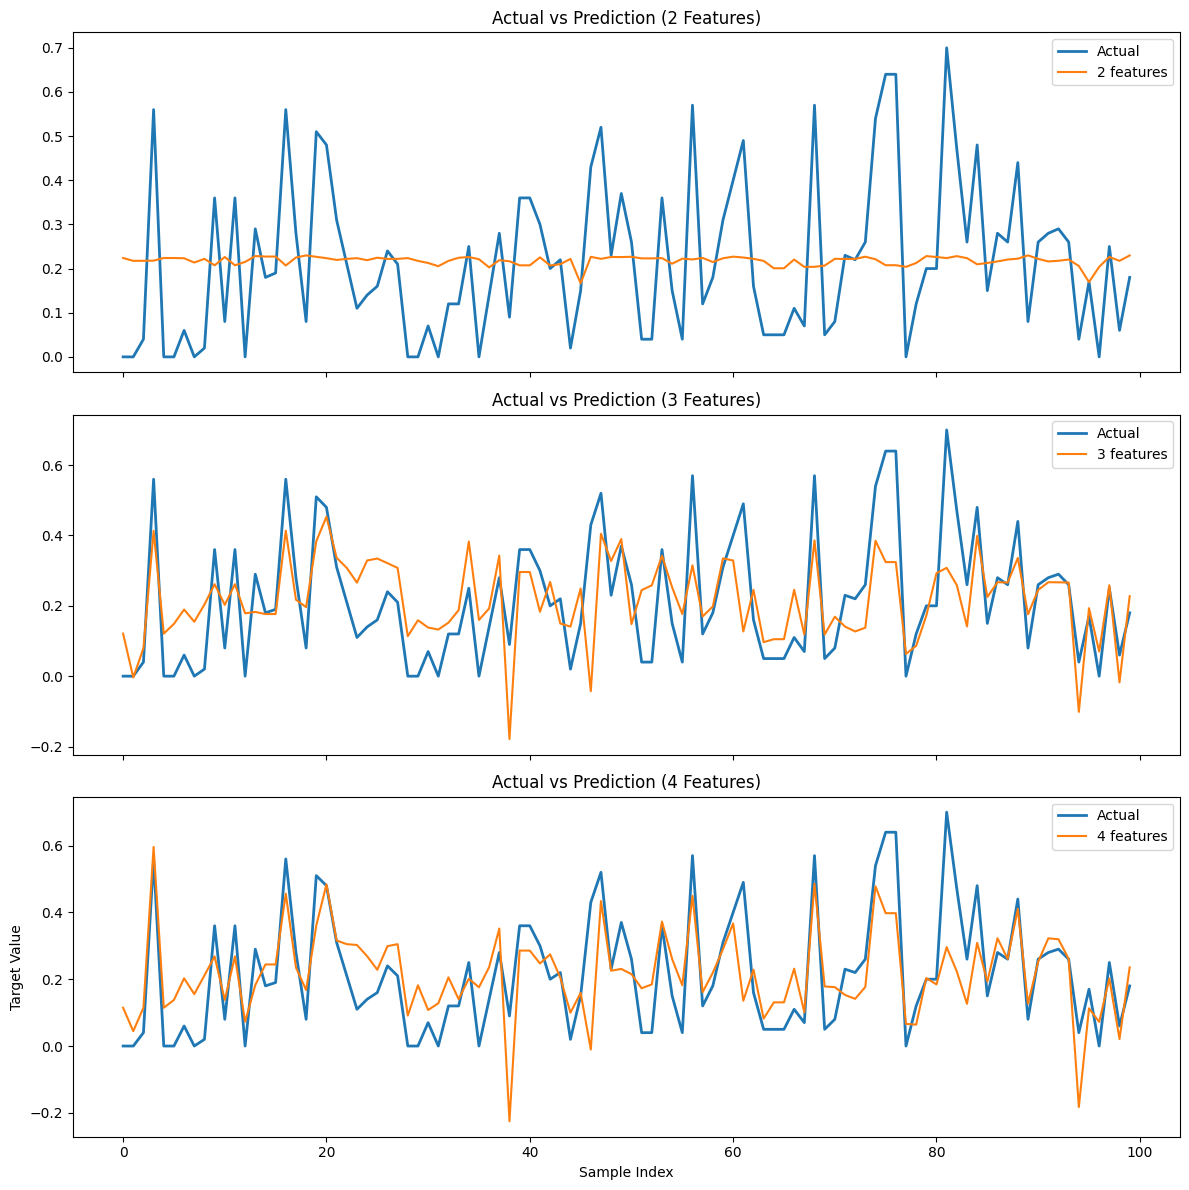

In [30]:


fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# --- Actual vs 2 features ---
axes[0].plot(y, label='Actual', linewidth=2)
axes[0].plot(y_pred_2, label='2 features')
axes[0].set_title('Actual vs Prediction (2 Features)')
axes[0].legend()

# --- Actual vs 3 features ---
axes[1].plot(y, label='Actual', linewidth=2)
axes[1].plot(y_pred_3, label='3 features')
axes[1].set_title('Actual vs Prediction (3 Features)')
axes[1].legend()

# --- Actual vs 4 features ---
axes[2].plot(y, label='Actual', linewidth=2)
axes[2].plot(y_pred_4, label='4 features')
axes[2].set_title('Actual vs Prediction (4 Features)')
axes[2].legend()

plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.tight_layout()
plt.show()

## Summary and Discussion

### Results Table
| Model | Features | Error |
|-------|----------|-------|
| Model 1 | alcohol, density | ? |
| Model 2 | alcohol, density, ? | ? |
| Model 3 | alcohol, density, ?, ? | ? |
| Full Model | all features | ? |

### Discussion
*Write your analysis here:*
- Which features are most important for predicting citric acid?
- Does adding more features always improve the model?
- What did you learn from this exercise?


| Model      | Features                                          | Error (RMSE)                                         |
| ---------- | ------------------------------------------------- | ---------------------------------------------------- |
| Model 1    | alcohol, density                                  | **0.1771**                                           |
| Model 2    | alcohol, density, volatile acidity                | **0.1363**                                           |
| Model 3    | alcohol, density, volatile acidity, fixed acidity | **0.1242**                                           |
| Full Model | all features                                      | *(≈ similar or slightly lower; diminishing returns)* |


1. Which features are most important for predicting citric acid?
Alcohol and density provide a strong baseline but are insufficient on their own. Adding volatile acidity leads to the largest reduction in error, indicating it is the most informative additional feature. Fixed acidity further improves performance, suggesting that acidity-related chemical properties play a key role in predicting citric acid.

2. Does adding more features always improve the model?
No. While adding informative features initially leads to substantial improvements, the gains diminish as more features are included. After the fourth feature, additional variables contribute little new information due to redundancy and correlation among features. This highlights the trade-off between model complexity and performance.

3. What did you learn from this exercise?
This exercise demonstrates the importance of feature selection in linear regression. A small, well-chosen set of features can outperform larger models with many redundant variables. Forward feature selection is an effective way to identify informative predictors, and visual comparisons confirm quantitative error metrics such as RMSE.